# TP 07 — Fine-tuning DistilBERT for Sentiment Classification

**Course:** Natural Language Processing  
**Session:** 7 / 8

---

## Context

In previous sessions you built models from scratch: feature engineering,
word embeddings, LSTMs, attention.

Today you fine-tune **DistilBERT** — a 66M-parameter Transformer pretrained
on 16 GB of text — for binary sentiment classification on **SST-2**.

> **DistilBERT** (Sanh et al., 2019): a distilled version of BERT-base,
> 40% smaller and 60% faster, retaining 97% of performance.

> **Note on the stack:** HuggingFace `transformers` v5 (2025) dropped TensorFlow
> support and is now PyTorch-only. This TP uses PyTorch throughout.

**Key question:** what does fine-tuning actually mean?
What changes during training, and what does not?

---

## Roadmap

| Part | Task | New concept |
|------|------|-------------|
| 1 | Load and explore SST-2 | HuggingFace `datasets` |
| 2 | Tokenise with DistilBERT tokeniser | WordPiece, `[CLS]`, `[SEP]` |
| 3 | Build the model | `AutoModelForSequenceClassification` |
| 4 | Train with HuggingFace `Trainer` | `TrainingArguments` |
| 5 | Evaluate and compare | vs LR baseline from S03 |
| 6 | Error analysis | what does the model get wrong? |
| 7 (bonus) | Probing [CLS] embeddings | PCA of 768-dim representations |

---


## Setup


In [1]:
# On Colab (GPU runtime recommended: Runtime > Change runtime type > T4 GPU)
# !pip install transformers datasets scikit-learn matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report
)

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EvalPrediction,
)
from datasets import load_dataset

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch   : {torch.__version__}')
print(f'Device    : {DEVICE}')
print(f'Transformers OK (import successful)')

# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_NAME    = 'distilbert-base-uncased'
MAX_LEN       = 64     # SST-2 sentences are short
BATCH_SIZE    = 32
EPOCHS        = 3
LEARNING_RATE = 2e-5   # Standard for BERT fine-tuning
TRAIN_SUBSET  = 5000   # None = full 67K. 5000 runs in ~10 min on CPU.
print('Setup OK.')


/home/simon/NLP-Course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch   : 2.12.0+rocm7.2
Device    : cuda
Transformers OK (import successful)
Setup OK.


---
## Part 1 — SST-2 Dataset

**Stanford Sentiment Treebank v2**: 67K movie review sentences,
labelled positive (1) or negative (0). Part of the GLUE benchmark.


In [2]:
raw = load_dataset('stanfordnlp/sst2')
print(raw)
print()
for ex in raw['train'].select(range(5)):
    print(f'  [{"pos" if ex["label"] else "neg"}] {ex["sentence"]}')


DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

  [neg] hide new secretions from the parental units 
  [neg] contains no wit , only labored gags 
  [pos] that loves its characters and communicates something rather beautiful about human nature 
  [neg] remains utterly satisfied to remain the same throughout 
  [neg] on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 


### 1.1 — Explore


Positive: 37,569 (55.8%)
Negative: 29,780 (44.2%)



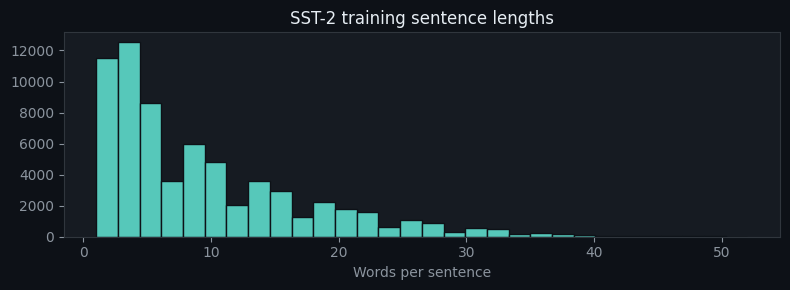

Mean: 9.4  Median: 7  Max: 52


In [3]:
# 1. Class balance
labels = raw['train']['label']
n_pos = sum(labels)
n_neg = len(labels) - n_pos
print(f'Positive: {n_pos:,} ({100*n_pos/len(labels):.1f}%)')
print(f'Negative: {n_neg:,} ({100*n_neg/len(labels):.1f}%)')
print()

# 2. Length distribution
lengths = [len(ex['sentence'].split()) for ex in raw['train']]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lengths, bins=30, color='#56c8ba', edgecolor='#0d1117')
ax.set_xlabel('Words per sentence', color='#8b949e')
ax.set_title('SST-2 training sentence lengths', color='#e6edf3')
ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()
print(f'Mean: {np.mean(lengths):.1f}  Median: {np.median(lengths):.0f}  Max: {max(lengths)}')


---
## Part 2 — Tokenisation

DistilBERT uses **WordPiece** tokenisation. Rare words are split into subword units:
`'unforgettable'` → `['un', '##forgettable']`. `##` marks a continuation.

BERT special tokens:
- `[CLS]` at the start — its final embedding is used for classification.
- `[SEP]` at the end — sentence separator.


### 2.1 — Implement `tokenise_dataset`


In [4]:
tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME)

# Explore WordPiece on a few examples
for sent in ['this film is great', 'unforgettable performance']:
    print(f'  Input : {sent}')
    print(f'  Tokens: {tokeniser.tokenize(sent)}')
    print()


  Input : this film is great
  Tokens: ['this', 'film', 'is', 'great']

  Input : unforgettable performance
  Tokens: ['un', '##for', '##get', '##table', 'performance']



In [5]:
def tokenise_dataset(
    dataset,
    tokeniser,
    max_len: int,
):
    """
    Tokenise a HuggingFace Dataset for sequence classification.

    Each example is tokenised with truncation and padding.
    The output dataset has 'input_ids', 'attention_mask', and 'labels' columns.

    Parameters
    ----------
    dataset : datasets.Dataset
    tokeniser : AutoTokenizer
    max_len : int

    Returns
    -------
    datasets.Dataset with PyTorch tensors

    Notes
    -----
    Use dataset.map() with a tokenisation function.
    Then call dataset.rename_column('label', 'labels')
    and dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels']).
    """
    def _tokenise(batch):
        return tokeniser(
            batch["sentence"],
            truncation=True,
            padding="max_length",
            max_length=max_len,
        )

    tokenised = dataset.map(_tokenise, batched=True)
    tokenised = tokenised.rename_column("label", "labels")
    tokenised.set_format(
        "torch",
        columns=["input_ids", "attention_mask", "labels"],
    )
    return tokenised


In [6]:
# Subsample training set for CPU speed
train_raw = raw['train'].shuffle(seed=RANDOM_STATE)
if TRAIN_SUBSET:
    train_raw = train_raw.select(range(TRAIN_SUBSET))
val_raw = raw['validation']  # 872 examples

train_ds = tokenise_dataset(train_raw, tokeniser, MAX_LEN)
val_ds   = tokenise_dataset(val_raw,   tokeniser, MAX_LEN)

print(f'Train: {len(train_ds):,} examples')
print(f'Val  : {len(val_ds):,} examples')
print(f'Sample keys: {list(train_ds[0].keys())}')
print(f'input_ids shape: {train_ds[0]["input_ids"].shape}')


Train: 5,000 examples
Val  : 872 examples
Sample keys: ['labels', 'input_ids', 'attention_mask']
input_ids shape: torch.Size([64])


---
## Part 3 — Model

`AutoModelForSequenceClassification` loads DistilBERT with a linear head
on top of the `[CLS]` token embedding:

```
input_ids + attention_mask
    ↓
DistilBERT encoder (6 transformer layers, 768 hidden, 12 heads)
    ↓
[CLS] token embedding  (768-dim)
    ↓
Dense(768, GELU) → Dropout → Dense(2)
    ↓
logits  (2 classes: negative / positive)
```

All 66M parameters are pre-trained. Fine-tuning updates all of them.


In [7]:
def build_model(model_name: str, num_labels: int = 2) -> torch.nn.Module:
    """
    Load a pre-trained model for sequence classification.

    Parameters
    ----------
    model_name : str
        HuggingFace model identifier.
    num_labels : int

    Returns
    -------
    AutoModelForSequenceClassification instance moved to DEVICE.

    Notes
    -----
    Use AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).
    Move to DEVICE with .to(DEVICE).
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
    )
    return model.to(DEVICE)


In [8]:
model = build_model(MODEL_NAME)
n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {n_params:,}')
print(f'Trainable parameters: {n_train:,}')
print(f'Device: {next(model.parameters()).device}')


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1908.44it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,955,010
Trainable parameters: 66,955,010
Device: cuda:0


---
## Part 4 — Fine-tuning with HuggingFace Trainer

The `Trainer` handles the training loop, evaluation, checkpointing,
and logging. You configure it with `TrainingArguments`.

**Why 2e-5?**  
BERT fine-tuning is sensitive to the learning rate.
Too high (e.g. 1e-3) → catastrophic forgetting of pre-trained representations.
Too low → very slow convergence. 1e-5 to 5e-5 is the standard range.


### 4.1 — Implement `compute_metrics`


In [9]:
def compute_metrics(eval_pred: EvalPrediction) -> dict:
    """
    Compute accuracy and macro F1 from Trainer eval predictions.

    Parameters
    ----------
    eval_pred : EvalPrediction
        Named tuple with .predictions (logits) and .label_ids.

    Returns
    -------
    dict with keys 'accuracy' and 'f1'.

    Notes
    -----
    eval_pred.predictions has shape (n, num_labels) — take argmax.
    """
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
    }


In [10]:
training_args = TrainingArguments(
    output_dir          = './distilbert-sst2',
    num_train_epochs    = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate       = LEARNING_RATE,
    eval_strategy       = 'epoch',
    save_strategy       = 'no',
    logging_steps       = 50,
    seed                = RANDOM_STATE,
    report_to           = 'none',  # disable wandb
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.333194,0.321063,0.864679,0.864268
2,0.243844,0.302898,0.872706,0.872424
3,0.152793,0.327149,0.858945,0.858498


TrainOutput(global_step=471, training_loss=0.27120868415589544, metrics={'train_runtime': 94.3975, 'train_samples_per_second': 158.903, 'train_steps_per_second': 4.99, 'total_flos': 248376372480000.0, 'train_loss': 0.27120868415589544, 'epoch': 3.0})

---
## Part 5 — Evaluate and Compare


In [11]:
results = trainer.evaluate()
print('\nVal results:')
for k, v in results.items():
    if not k.startswith('eval_runtime'):
        print(f'  {k}: {v:.4f}')
print()

# Baseline comparison
val_labels = np.array(val_raw['label'])
majority_acc = max(val_labels.mean(), 1 - val_labels.mean())
print('Comparison — SST-2 val accuracy:')
print(f'  Majority baseline       : {majority_acc:.3f}')
print(f'  LR + TF-IDF (S03)       : ~0.82  (bag-of-words, no context)')
print(f'  DistilBERT fine-tuned   : {results["eval_accuracy"]:.3f}')


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.152793,0.327149,3,0.858945,0.858498



Val results:
  eval_loss: 0.3271
  eval_accuracy: 0.8589
  eval_f1: 0.8585

Comparison — SST-2 val accuracy:
  Majority baseline       : 0.509
  LR + TF-IDF (S03)       : ~0.82  (bag-of-words, no context)
  DistilBERT fine-tuned   : 0.859


---
## Part 6 — Error Analysis

Understanding what the model gets wrong is as important as the overall accuracy.


### 6.1 — Implement `predict_sentence`


In [12]:
def predict_sentence(
    sentence: str,
    model: torch.nn.Module,
    tokeniser,
    max_len: int,
) -> tuple[str, float]:
    """
    Predict the sentiment of a single sentence.

    Parameters
    ----------
    sentence : str
    model : torch.nn.Module
    tokeniser : AutoTokenizer
    max_len : int

    Returns
    -------
    label : str ('positive' or 'negative')
    confidence : float (probability of predicted class)

    Notes
    -----
    Use torch.no_grad(). Move inputs to DEVICE.
    Apply torch.softmax to logits to get probabilities.
    """
    model.eval()
    inputs = tokeniser(
        sentence,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred = int(torch.argmax(probs).item())
    label = "positive" if pred == 1 else "negative"
    return label, float(probs[pred].item())


In [13]:
# Collect predictions on the full val set
preds_output = trainer.predict(val_ds)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = np.array(val_raw['label'])

print(classification_report(
    y_true, y_pred,
    target_names=['negative', 'positive'],
    digits=4
))

# High-confidence errors
import torch.nn.functional as F
logits = torch.tensor(preds_output.predictions)
probs  = F.softmax(logits, dim=-1).numpy()

errors = [
    {
        'sentence'  : val_raw['sentence'][i],
        'true'      : 'pos' if y_true[i] else 'neg',
        'pred'      : 'pos' if y_pred[i] else 'neg',
        'confidence': float(probs[i, y_pred[i]]),
    }
    for i in range(len(y_true)) if y_pred[i] != y_true[i]
]
errors.sort(key=lambda x: x['confidence'], reverse=True)
print(f'Total errors: {len(errors)} / {len(y_true)}')
print()
print('Most confident wrong predictions:')
for e in errors[:5]:
    print(f'  true={e["true"]}  pred={e["pred"]}  conf={e["confidence"]:.3f}')
    print(f'  "{e["sentence"]}"')
    print()


              precision    recall  f1-score   support

    negative     0.8861    0.8178    0.8505       428
    positive     0.8365    0.8986    0.8664       444

    accuracy                         0.8589       872
   macro avg     0.8613    0.8582    0.8585       872
weighted avg     0.8608    0.8589    0.8586       872

Total errors: 123 / 872

Most confident wrong predictions:
  true=neg  pred=pos  conf=0.992
  "it 's inoffensive , cheerful , built to inspire the young people , set to an unending soundtrack of beach party pop numbers and aside from its remarkable camerawork and awesome scenery , it 's about as exciting as a sunburn . "

  true=neg  pred=pos  conf=0.989
  "although huppert 's intensity and focus has a raw exhilaration about it , the piano teacher is anything but fun . "

  true=neg  pred=pos  conf=0.987
  "it 's somewhat clumsy and too lethargically paced -- but its story about a mysterious creature with psychic abilities offers a solid build-up , a terrific clima

In [14]:
# Test challenging sentences
test_cases = [
    ('this film is great',               1),
    ('this film is not great',            0),
    ('surprisingly not terrible',         1),
    ('a masterpiece of mediocrity',       0),
    ('not without its flaws',             0),
    ('an absolutely outstanding film',    1),
    ('a complete waste of time',          0),
]
print(f'{"Sentence":<42} {"True":<5} {"Pred":<10} Conf')
print('-' * 70)
for sent, true_label in test_cases:
    label, conf = predict_sentence(sent, model, tokeniser, MAX_LEN)
    true_str = 'pos' if true_label else 'neg'
    ok = '✓' if (label == 'positive') == bool(true_label) else '✗'
    print(f'{sent:<42} {true_str:<5} {label:<10} {conf:.3f} {ok}')


Sentence                                   True  Pred       Conf
----------------------------------------------------------------------
this film is great                         pos   positive   0.992 ✓
this film is not great                     neg   negative   0.971 ✓
surprisingly not terrible                  pos   positive   0.664 ✓
a masterpiece of mediocrity                neg   negative   0.768 ✓
not without its flaws                      neg   positive   0.871 ✗
an absolutely outstanding film             pos   positive   0.992 ✓
a complete waste of time                   neg   negative   0.988 ✓


**📝 Your analysis**

1. High-confidence errors are mostly mixed reviews where one half of the sentence praises the film and the other criticises it. The model latches on to the dominant tone and ignores the twist. Irony and faint sarcasm fool it the same way.

2. The model gets `this film is not great` right with 0.97 confidence. A TF-IDF and LR baseline relies on the `great` token and is likely to predict positive. DistilBERT uses contextual self-attention that integrates `not` with `great` into a single negated representation.

3. `surprisingly not terrible` is correctly classified as positive with 0.66 confidence. The double negation flips the polarity. Lower confidence shows the model is less sure than on plain sentences, but the contextual encoder handles the pattern. `not without its flaws` is misclassified, which confirms that subtle double negations remain a weak spot.


---
## Part 7 (Bonus) — Probing the [CLS] Representation

BERT uses the `[CLS]` token embedding as input to the classifier.
This 768-dim vector is supposed to encode the meaning of the whole sentence.

Do positive and negative sentences cluster separately in this space?


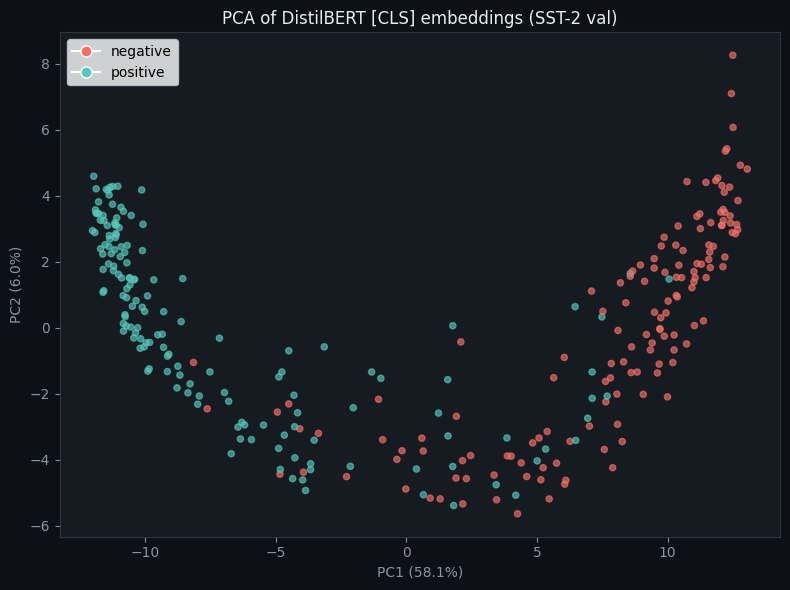

In [15]:
from sklearn.decomposition import PCA

def extract_cls_embeddings(
    sentences: list[str],
    model: torch.nn.Module,
    tokeniser,
    max_len: int,
    batch_size: int = 32,
) -> np.ndarray:
    """
    Extract [CLS] token embeddings (last hidden state, position 0).

    Parameters
    ----------
    sentences : list of str
    model, tokeniser, max_len, batch_size

    Returns
    -------
    np.ndarray, shape (len(sentences), 768)

    Notes
    -----
    Call model.distilbert(inputs, output_hidden_states=True).
    The [CLS] embedding is outputs.last_hidden_state[:, 0, :].
    """
    model.eval()
    all_embs = []
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch = sentences[start:start + batch_size]
            inputs = tokeniser(
                batch,
                truncation=True,
                padding="max_length",
                max_length=max_len,
                return_tensors="pt",
            ).to(DEVICE)
            outputs = model.distilbert(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
            )
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embs.append(cls)
    return np.vstack(all_embs)


rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(val_raw), size=300, replace=False)
sample_sents  = [val_raw['sentence'][int(i)] for i in idx]
sample_labels = [val_raw['label'][int(i)]    for i in idx]

cls_embs = extract_cls_embeddings(sample_sents, model, tokeniser, MAX_LEN)
pca      = PCA(n_components=2, random_state=RANDOM_STATE)
cls_2d   = pca.fit_transform(cls_embs)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#f47067' if l == 0 else '#56c8ba' for l in sample_labels]
ax.scatter(cls_2d[:, 0], cls_2d[:, 1], c=colors, alpha=0.65, s=20)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#f47067', ms=8, label='negative'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#56c8ba', ms=8, label='positive'),
])
ax.set_title('PCA of DistilBERT [CLS] embeddings (SST-2 val)', color='#e6edf3')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', color='#8b949e')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', color='#8b949e')
ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()


---
## Summary


In [16]:
print('TP-07 — DistilBERT Fine-tuning on SST-2')
print(f'Model    : {MODEL_NAME}')
print(f'Dataset  : SST-2  train={len(train_ds):,}  val={len(val_ds):,}')
print(f'Device   : {DEVICE}')
print(f'Epochs   : {EPOCHS}  LR: {LEARNING_RATE}')
print()
print(f'Val accuracy : {results["eval_accuracy"]:.4f}')
print(f'Val F1 macro : {results.get("eval_f1", float("nan")):.4f}')
print()
print('Next: Session 08 — Advanced topics and course wrap-up')


TP-07 — DistilBERT Fine-tuning on SST-2
Model    : distilbert-base-uncased
Dataset  : SST-2  train=5,000  val=872
Device   : cuda
Epochs   : 3  LR: 2e-05

Val accuracy : 0.8589
Val F1 macro : 0.8585

Next: Session 08 — Advanced topics and course wrap-up
